# Random-Walk Metropolis with BlackJAX

The preceding section derived the Metropolis--Hastings transition and the diagnostics needed to assess a finite run. This section implements a Gaussian random-walk kernel with BlackJAX {cite:p}`cabezas2024blackjax`. The example separates warmup from inference, retains every inference draw, and checks the computation against properties of the target that are known exactly.


In [1]:
import blackjax
import jax
import jax.numpy as jnp
import jax.random as jrandom
from jax import lax, vmap
from jax.scipy.stats import multivariate_normal

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
from html import escape
from IPython.display import display
from scipy.stats import rankdata

jax.config.update("jax_enable_x64", True)
matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "png")

FIGURE_SIZES = {
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_tall": (3.55, 3.05),
}

CHAIN_STYLES = [
    ("0.10", "-"),
    ("0.35", "--"),
    ("0.55", "-."),
    ("0.70", ":"),
]

mpl.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.frameon": False,
        "lines.linewidth": 1.1,
    }
)


def finish_axes(axes, *, boxed=False):
    for ax in np.atleast_1d(axes).ravel():
        ax.grid(False)
        ax.spines["top"].set_visible(boxed)
        ax.spines["right"].set_visible(boxed)
    return axes


def display_book_table(
    headers,
    rows,
    latex_source,
    *,
    html_headers=None,
    html_rows=None,
):
    # Display one compact table in HTML, LaTeX, and plain-text formats.
    if html_headers is None:
        html_headers = [escape(str(value)) for value in headers]
    if html_rows is None:
        html_rows = [[escape(str(value)) for value in row] for row in rows]
    head = "".join(f"<th>{value}</th>" for value in html_headers)
    body = "".join(
        "<tr>" + "".join(f"<td>{value}</td>" for value in row) + "</tr>"
        for row in html_rows
    )
    html_source = (
        '<table class="table table-sm">'
        f"<thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"
    )
    widths = [max(len(str(value)) for value in [header] + [row[i] for row in rows])
              for i, header in enumerate(headers)]
    plain_rows = [headers] + rows
    plain_source = "\n".join(
        "  ".join(str(value).ljust(widths[i]) for i, value in enumerate(row))
        for row in plain_rows
    )
    display(
        {
            "text/plain": plain_source,
            "text/html": html_source,
            "text/latex": latex_source,
        },
        raw=True,
    )


## Banana-shaped target

Let

$$
V=
\begin{bmatrix}V_1\\V_2\end{bmatrix}
\sim
\mathcal{N}\!\left(
0,
\Sigma_\rho
\right),
\qquad
\Sigma_\rho=
\begin{bmatrix}
1 & \rho\\
\rho & 1
\end{bmatrix},
$$

and define

$$
X_1=aV_1,
\qquad
X_2=\frac{V_2}{a}+b\left(V_1^2+a^2\right).
$$

Write $X=(X_1,X_2)^{\mathsf T}\in\mathbb{R}^2$ and let $x=(x_1,x_2)^{\mathsf T}\in\mathbb{R}^2$ denote one of its realizations. We use $a=1.15$, $b=0.5$, and $\rho=0.9$, the parameters of the banana-shaped example in {cite:t}`wang2019hmcsubset`. The inverse transformation is

$$
v_1(x)=\frac{x_1}{a},
\qquad
v_2(x)=a\left[x_2-b\left(\left(\frac{x_1}{a}\right)^2+a^2\right)\right].
$$

Its Jacobian determinant is one because

$$
\det
\begin{bmatrix}
\partial v_1/\partial x_1 & \partial v_1/\partial x_2\\
\partial v_2/\partial x_1 & \partial v_2/\partial x_2
\end{bmatrix}
=
\det
\begin{bmatrix}
a^{-1} & 0\\
-2bx_1/a & a
\end{bmatrix}
=1.
$$

Therefore the normalized target density is $\pi(x)=\phi_{\Sigma_\rho}(v(x))$, where $\phi_{\Sigma_\rho}$ is the centered Gaussian density with covariance $\Sigma_\rho$.


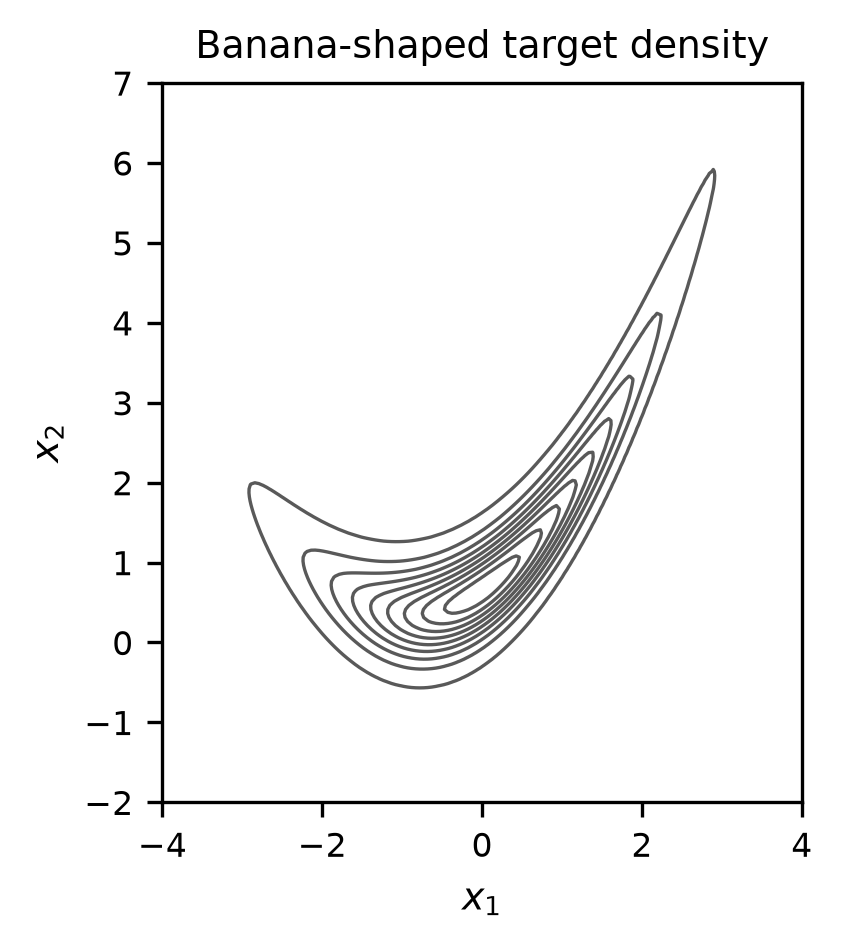

In [2]:
a = 1.15
b = 0.5
rho = 0.9
correlation = jnp.array([[1.0, rho], [rho, 1.0]])


def banana_logdensity(x):
    # Log density induced by the unit-Jacobian banana transformation.
    x1, x2 = x
    u1 = x1 / a
    u2 = a * (x2 - b * (u1**2 + a**2))
    u = jnp.array([u1, u2])
    return multivariate_normal.logpdf(u, jnp.zeros(2), correlation)


grid_x = jnp.linspace(-4.0, 4.0, 160)
grid_y = jnp.linspace(-2.0, 7.0, 180)
X_grid, Y_grid = jnp.meshgrid(grid_x, grid_y)
grid_points = jnp.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
target_density = jnp.exp(vmap(banana_logdensity)(grid_points)).reshape(X_grid.shape)


def draw_target_contours(ax):
    maximum = float(jnp.max(target_density))
    levels = np.linspace(0.04 * maximum, 0.92 * maximum, 9)
    ax.contour(
        np.asarray(X_grid),
        np.asarray(Y_grid),
        np.asarray(target_density),
        levels=levels,
        colors="0.35",
        linewidths=0.8,
    )
    ax.set_xlim(-4.0, 4.0)
    ax.set_ylim(-2.0, 7.0)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    finish_axes(ax, boxed=True)
    return ax


fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_tall"], constrained_layout=True)
draw_target_contours(ax)
ax.set_title("Banana-shaped target density");


## Gaussian random-walk kernel

At state $x$, the proposal is

$$
X'=x+\varepsilon,
\qquad
\varepsilon\sim\mathcal{N}(0,\sigma^2I_2).
$$

Here $\sigma>0$ is the proposal scale and $I_2$ is the $2{\times}2$ identity matrix.

Thus $q(x'\mid x)=q(x\mid x')$, and the proposal-density ratio cancels from the Metropolis--Hastings acceptance probability:

$$
\alpha(x,x')
=
\min\!\left\{1,\frac{\pi(x')}{\pi(x)}\right\}.
$$

We fix $\sigma=0.7$ before collecting inference draws. This value is suitable for the demonstration; in an application it should be selected in a separate pilot or warmup calculation rather than tuned using retained inference draws.


In [3]:
proposal_scale = 0.7

kernel = blackjax.additive_step_random_walk.normal_random_walk(
    banana_logdensity,
    proposal_scale * jnp.ones(2),
)


def scan_step(carry, _):
    key, state = carry
    key, transition_key = jrandom.split(key)
    next_state, info = kernel.step(transition_key, state)
    output = (next_state.position, info.is_accepted)
    return (key, next_state), output


def run_chain(key, initial_state, num_steps):
    (_, final_state), output = lax.scan(
        scan_step,
        (key, initial_state),
        None,
        length=num_steps,
    )
    positions, is_accepted = output
    return final_state, positions, is_accepted


def demo_scan_step(carry, _):
    key, state = carry
    key, transition_key = jrandom.split(key)
    proposal_key, _ = jrandom.split(transition_key)
    candidate = state.position + proposal_scale * jrandom.normal(
        proposal_key,
        shape=state.position.shape,
    )
    next_state, info = kernel.step(transition_key, state)
    output = (next_state.position, info.is_accepted, candidate)
    return (key, next_state), output


def run_demo(key, initial_state, num_steps):
    (_, final_state), output = lax.scan(
        demo_scan_step,
        (key, initial_state),
        None,
        length=num_steps,
    )
    positions, is_accepted, candidates = output
    return final_state, positions, is_accepted, candidates


master_key = jrandom.PRNGKey(20260919)
demo_key, warmup_key, inference_key = jrandom.split(master_key, 3)


{numref}`fig-mcmc-random-walk-proposals` makes rejection visible. A filled circle marks an accepted candidate. A cross marks a rejected candidate; after rejection, the state is repeated.


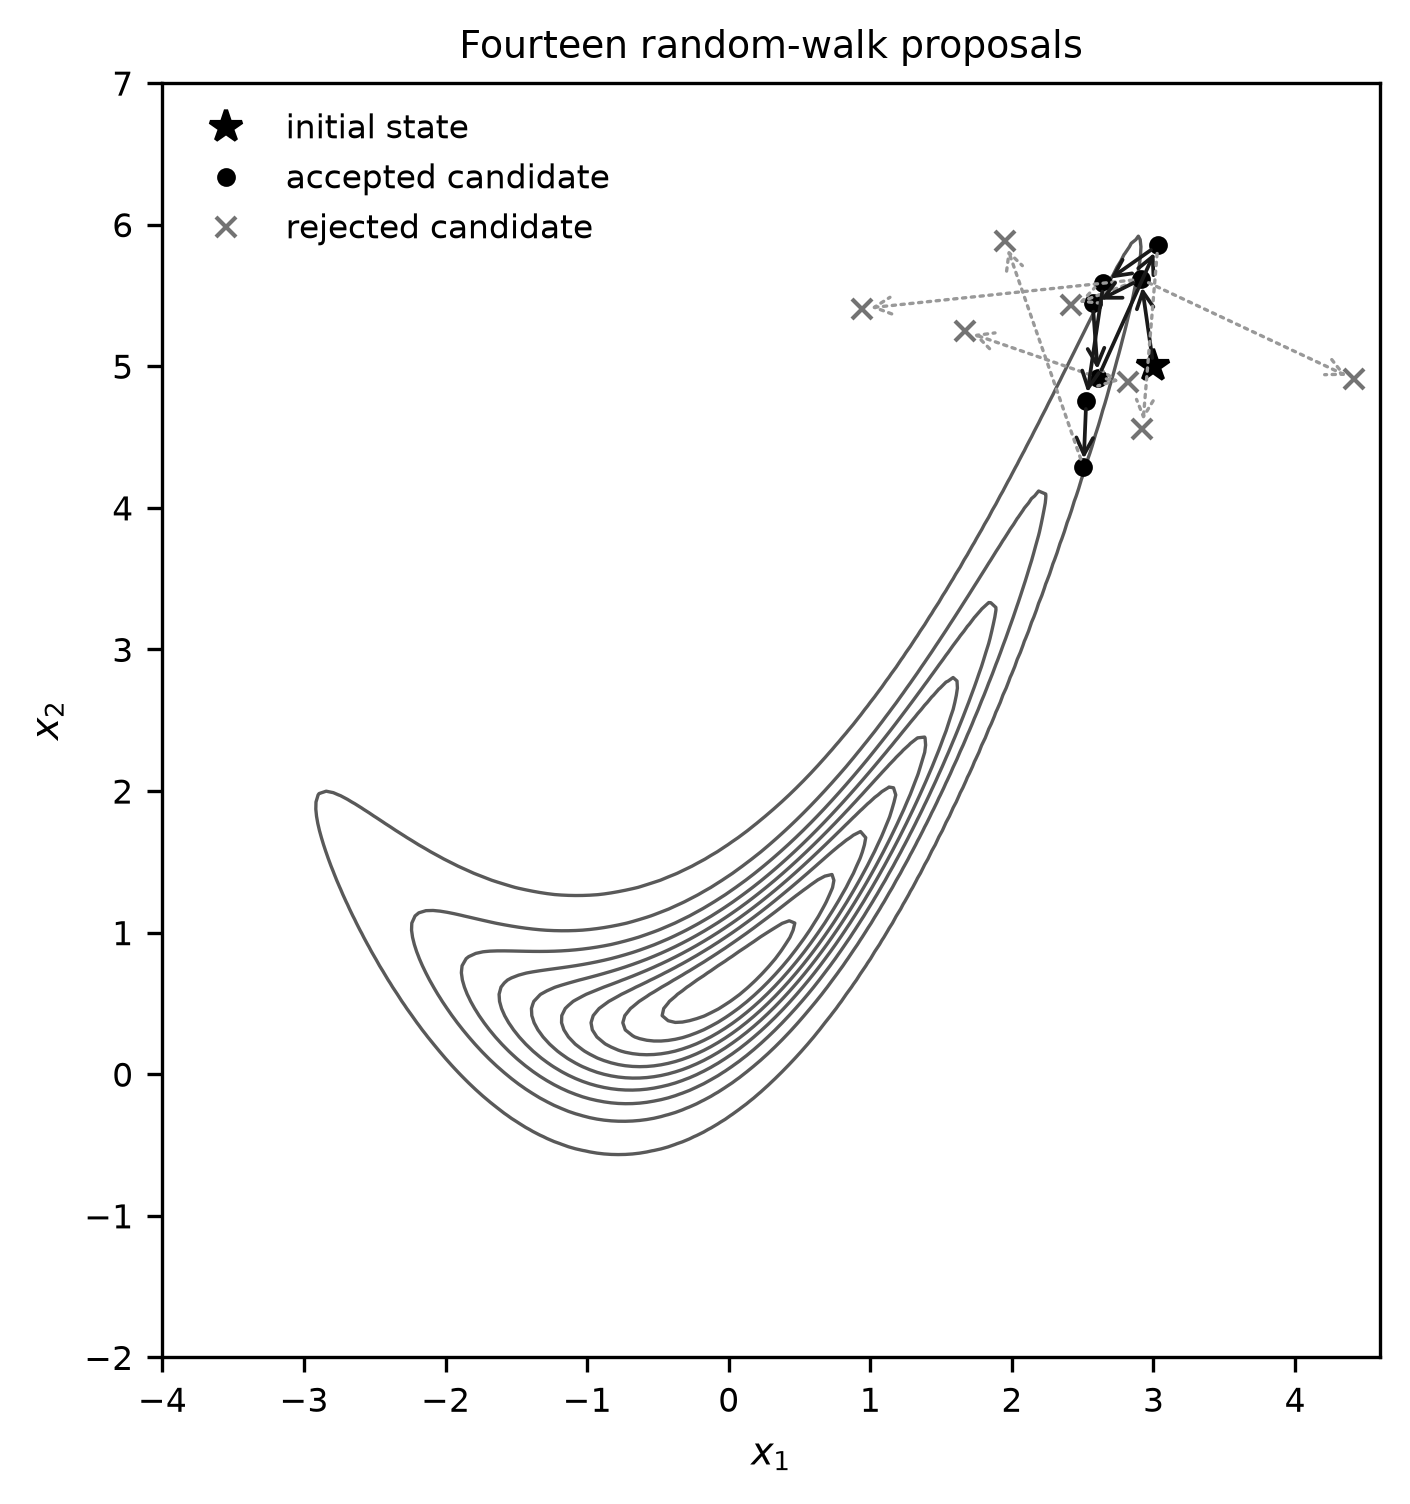

In [4]:
demo_initial_position = jnp.array([3.0, 5.0])
_, demo_states, demo_accept, demo_proposals = run_demo(
    demo_key,
    kernel.init(demo_initial_position),
    14,
)

demo_previous = np.vstack(
    [np.asarray(demo_initial_position), np.asarray(demo_states[:-1])]
)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"], constrained_layout=True)
draw_target_contours(ax)
ax.set_xlim(-4.0, 4.6)
ax.plot(
    demo_initial_position[0],
    demo_initial_position[1],
    marker="*",
    color="black",
    markersize=8,
    linestyle="none",
    label="initial state",
)

accepted_label_used = False
rejected_label_used = False
for previous, proposal, accepted in zip(
    demo_previous,
    np.asarray(demo_proposals),
    np.asarray(demo_accept),
):
    if accepted:
        ax.annotate(
            "",
            xy=proposal,
            xytext=previous,
            arrowprops={"arrowstyle": "->", "color": "0.10", "linewidth": 0.9},
        )
        ax.plot(
            proposal[0],
            proposal[1],
            marker="o",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=3.5,
            linestyle="none",
            label="accepted candidate" if not accepted_label_used else None,
        )
        accepted_label_used = True
    else:
        ax.annotate(
            "",
            xy=proposal,
            xytext=previous,
            arrowprops={
                "arrowstyle": "->",
                "color": "0.60",
                "linewidth": 0.8,
                "linestyle": ":",
            },
        )
        ax.plot(
            proposal[0],
            proposal[1],
            marker="x",
            color="0.45",
            markersize=5,
            linestyle="none",
            label="rejected candidate" if not rejected_label_used else None,
        )
        rejected_label_used = True

ax.legend(loc="upper left")
ax.set_title("Fourteen random-walk proposals");


## Warmup and inference draws

We run four chains from dispersed initial positions. The first $3{,}000$ iterations form a pre-specified warmup phase used only to reduce sensitivity to the initial positions. The kernel has no adaptive parameter in this example. We then start a separate inference phase from the four warmup endpoints and retain all $40{,}000$ draws from each chain.

The warmup length is not inferred from a retrospective threshold crossing. Instead, the post-warmup draws are assessed using multiple-chain plots and diagnostics.


In [5]:
initial_positions = jnp.array(
    [
        [-4.0, 1.0],
        [-1.0, -1.0],
        [1.0, 4.0],
        [4.0, 6.0],
    ]
)

num_chains = initial_positions.shape[0]
num_warmup = 3_000
num_draws = 40_000

warmup_keys = jrandom.split(warmup_key, num_chains)
initial_states = vmap(kernel.init)(initial_positions)
warmup_final_states, warmup_samples, warmup_accepted = vmap(
    run_chain,
    in_axes=(0, 0, None),
)(warmup_keys, initial_states, num_warmup)

inference_keys = jrandom.split(inference_key, num_chains)
_, samples, inference_accepted = vmap(
    run_chain,
    in_axes=(0, 0, None),
)(inference_keys, warmup_final_states, num_draws)

samples.shape


(4, 40000, 2)

The trace display includes the entire warmup and the first $2{,}000$ inference draws. The vertical line marks the boundary; all numerical diagnostics below use the complete inference phase.


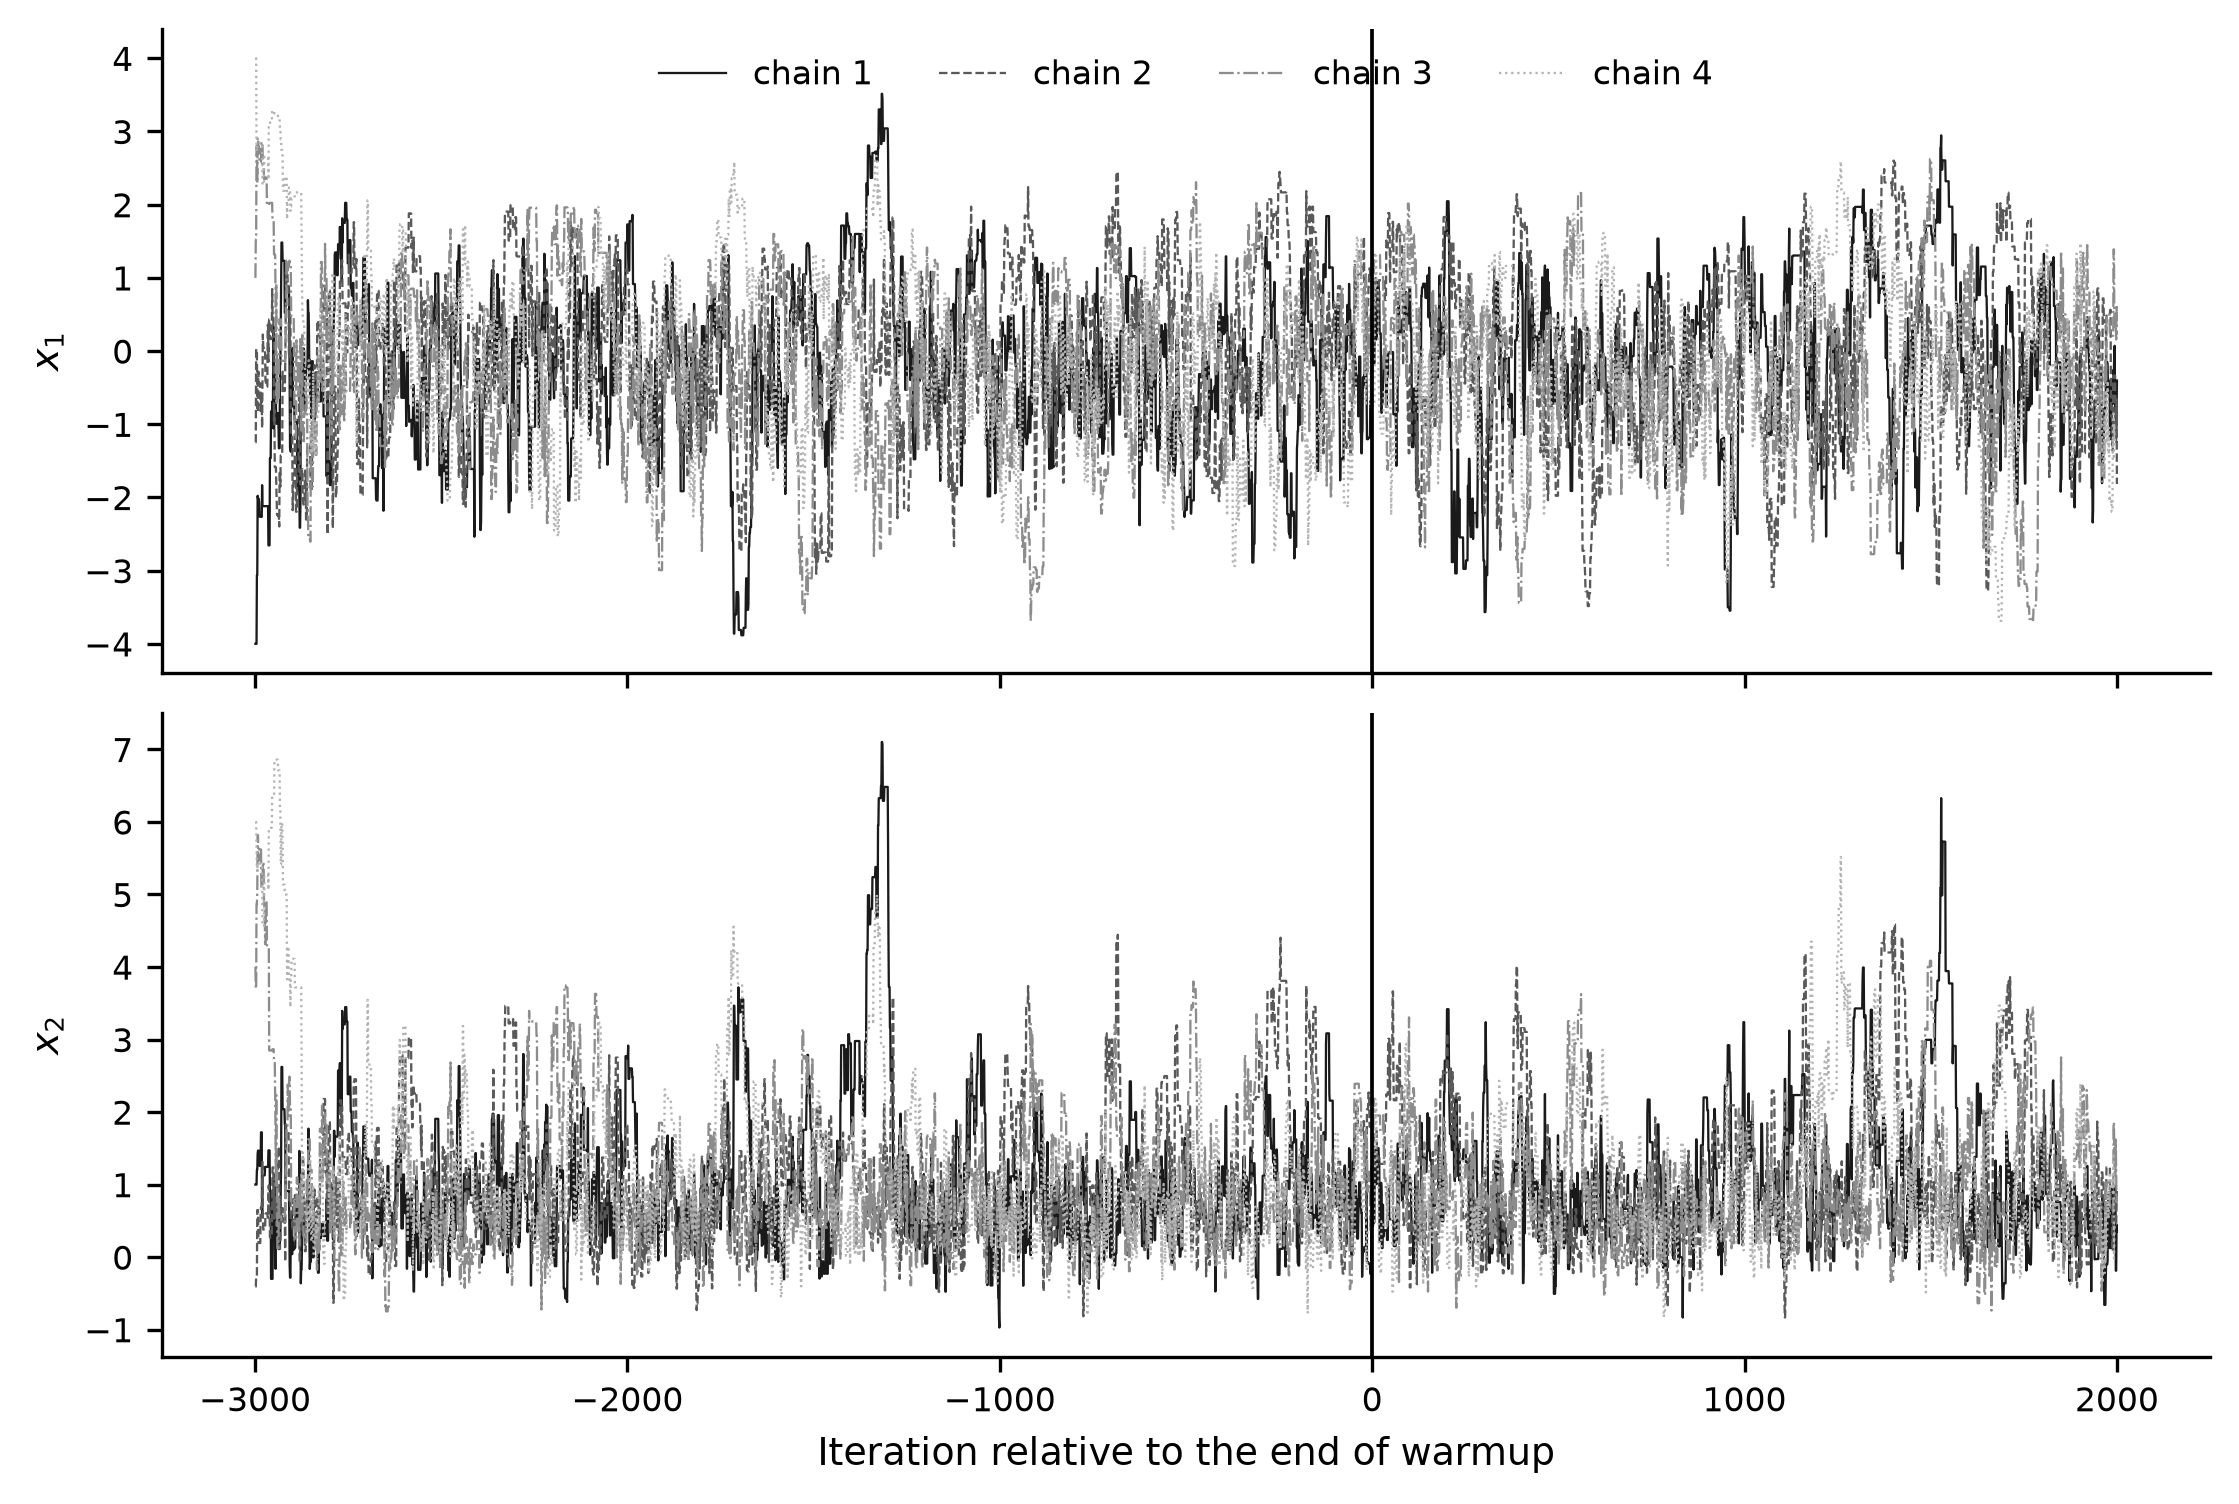

In [6]:
trace_draws = 2_000
trace_values = np.concatenate(
    [np.asarray(warmup_samples), np.asarray(samples[:, :trace_draws])],
    axis=1,
)
trace_iteration = np.arange(-num_warmup + 1, trace_draws + 1)

fig, axes = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=FIGURE_SIZES["full_standard"],
    constrained_layout=True,
)
for chain in range(num_chains):
    color, linestyle = CHAIN_STYLES[chain]
    for coordinate, ax in enumerate(axes):
        ax.plot(
            trace_iteration,
            trace_values[chain, :, coordinate],
            color=color,
            linestyle=linestyle,
            linewidth=0.55,
            rasterized=True,
            label=f"chain {chain + 1}" if coordinate == 0 else None,
        )

for coordinate, ax in enumerate(axes):
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_ylabel(fr"$x_{coordinate + 1}$")
axes[0].legend(ncol=4, loc="upper center")
axes[-1].set_xlabel("Iteration relative to the end of warmup")
finish_axes(axes);


## Multiple-chain diagnostics

We compute the rank-normalized split and folded $\widehat R$, together with bulk and tail effective sample sizes, on the post-warmup draws {cite:p}`vehtari2021rank`. The acceptance rate describes the kernel's local behavior but does not establish convergence by itself.


In [7]:
rhat = np.asarray(blackjax.rhat(samples))
bulk_ess = np.asarray(blackjax.ess_bulk(samples))
tail_ess = np.asarray(blackjax.ess_tail(samples))
acceptance_rate = np.asarray(inference_accepted).mean(axis=1)

diagnostic_rows = [
    ["Rank-normalized split/folded R-hat", f"{rhat[0]:.4f}", f"{rhat[1]:.4f}"],
    ["Bulk ESS", f"{bulk_ess[0]:.0f}", f"{bulk_ess[1]:.0f}"],
    ["Tail ESS", f"{tail_ess[0]:.0f}", f"{tail_ess[1]:.0f}"],
]
diagnostic_latex = rf'''
\begin{{tabular}}{{lrr}}
\hline
Quantity & $x_1$ & $x_2$ \\
\hline
Rank-normalized split/folded $\widehat R$ & {rhat[0]:.4f} & {rhat[1]:.4f} \\
Bulk ESS & {bulk_ess[0]:.0f} & {bulk_ess[1]:.0f} \\
Tail ESS & {tail_ess[0]:.0f} & {tail_ess[1]:.0f} \\
\hline
\end{{tabular}}
'''
math_class = 'class="math notranslate nohighlight"'
diagnostic_html_headers = [
    "Quantity",
    f"<span {math_class}>\\(x_1\\)</span>",
    f"<span {math_class}>\\(x_2\\)</span>",
]
diagnostic_html_rows = [
    [
        f"Rank-normalized split/folded <span {math_class}>\\(\\widehat R\\)</span>",
        diagnostic_rows[0][1],
        diagnostic_rows[0][2],
    ],
    diagnostic_rows[1],
    diagnostic_rows[2],
]
display_book_table(
    ["Quantity", "x1", "x2"],
    diagnostic_rows,
    diagnostic_latex,
    html_headers=diagnostic_html_headers,
    html_rows=diagnostic_html_rows,
)
print(
    "Per-chain acceptance rates: "
    + ", ".join(f"{rate:.3f}" for rate in acceptance_rate)
)


Quantity,\(x_1\),\(x_2\)
Rank-normalized split/folded \(\widehat R\),1.0005,1.0006
Bulk ESS,2612,3012
Tail ESS,2061,2139


Per-chain acceptance rates: 0.402, 0.399, 0.401, 0.401


Rank histograms provide a complementary graphical check. If the chains explore the same distribution, each chain should contribute comparably throughout the pooled ranks. Exact uniformity is neither expected nor required.


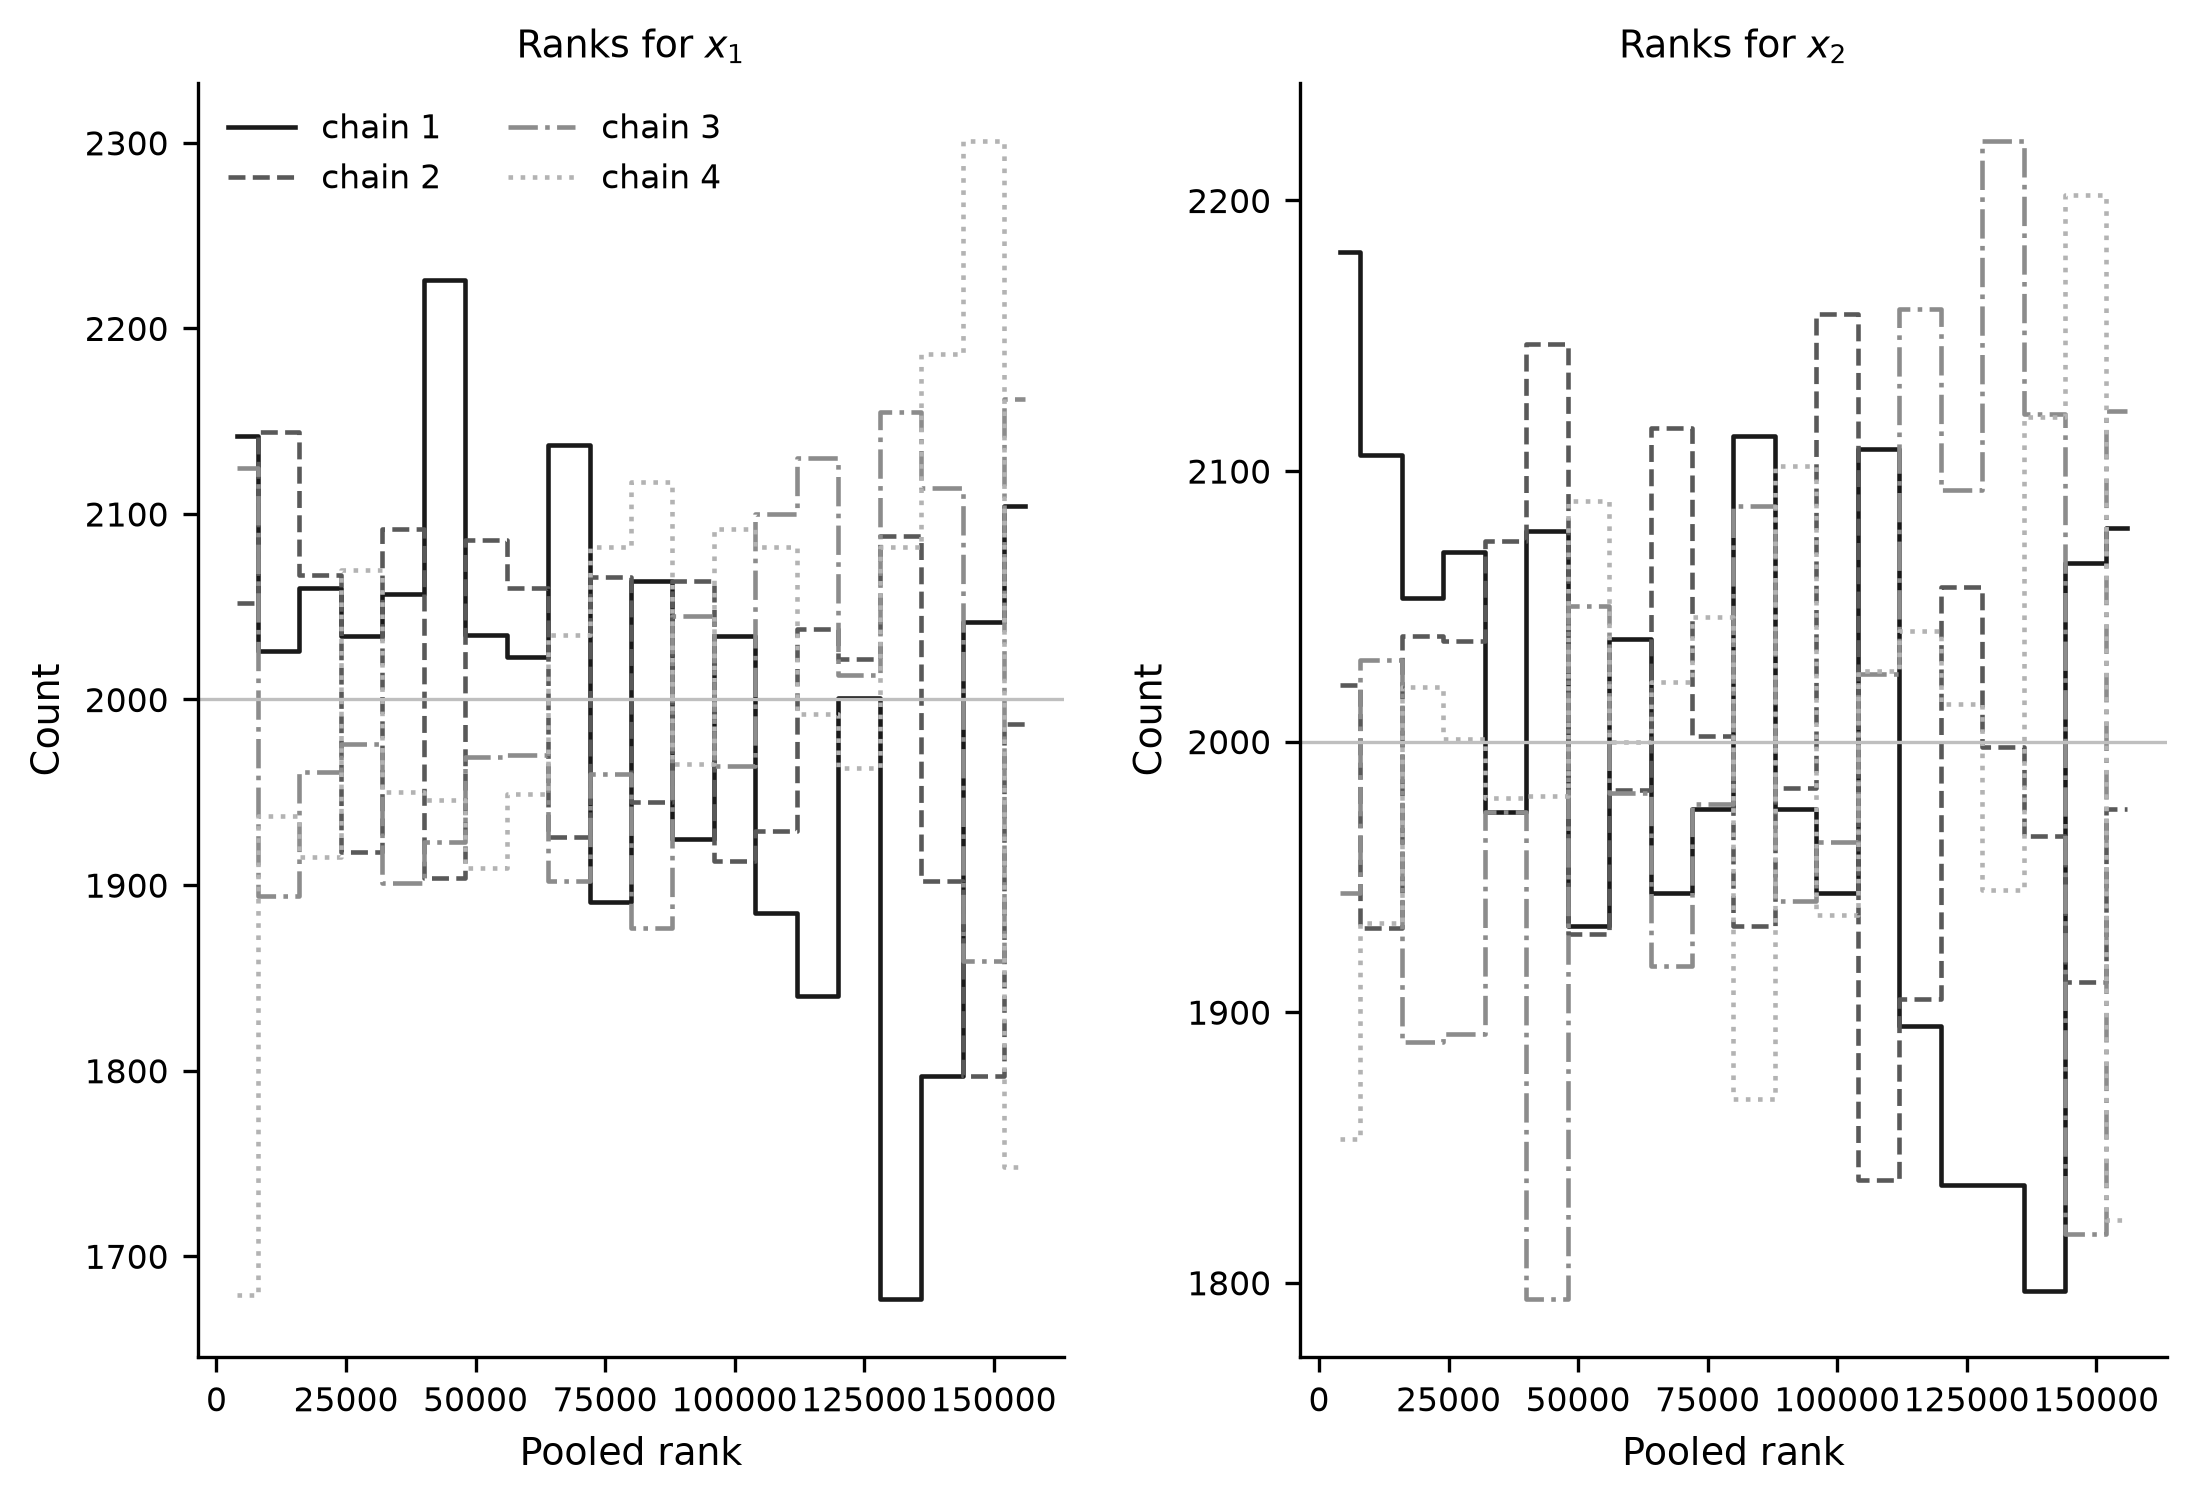

In [8]:
num_rank_bins = 20
fig, axes = plt.subplots(
    1,
    2,
    figsize=FIGURE_SIZES["full_standard"],
    constrained_layout=True,
)

for coordinate, ax in enumerate(axes):
    pooled = np.asarray(samples[:, :, coordinate])
    ranks = rankdata(pooled.ravel(), method="average").reshape(pooled.shape)
    bin_edges = np.linspace(0.5, ranks.size + 0.5, num_rank_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    for chain in range(num_chains):
        color, linestyle = CHAIN_STYLES[chain]
        counts, _ = np.histogram(ranks[chain], bins=bin_edges)
        ax.step(
            bin_centers,
            counts,
            where="mid",
            color=color,
            linestyle=linestyle,
            label=f"chain {chain + 1}",
        )
    ax.axhline(num_draws / num_rank_bins, color="0.75", linewidth=0.8)
    ax.set_title(fr"Ranks for $x_{coordinate + 1}$")
    ax.set_xlabel("Pooled rank")
    ax.set_ylabel("Count")

axes[0].legend(ncol=2)
finish_axes(axes);


## Monte Carlo precision and an exact check

The transformation gives several exact moments:

$$
\begin{aligned}
\mathbb{E}[X_1]&=0,
&\mathbb{E}[X_2]&=b(1+a^2),\\
\mathbb{E}[X_1^2]&=a^2,
&\mathbb{E}[X_1X_2]&=\rho,\\
\operatorname{Var}(X_2)&=a^{-2}+2b^2.
\end{aligned}
$$

The last identity uses $\operatorname{Cov}(V_2,V_1^2)=0$, since every centered third-order Gaussian moment vanishes. Hence

$$
\mathbb{E}[X_2^2]
=
a^{-2}+2b^2+b^2(1+a^2)^2.
$$

For each moment $g(X)$, the table estimates

$$
\operatorname{MCSE}(\bar g)
\approx
\sqrt{\frac{\widehat{\operatorname{Var}}(g(X))}{N_{\mathrm{eff},g}}}.
$$

Here $\bar g$ is the average of $g(X)$ over all retained chains and draws, $\widehat{\operatorname{Var}}(g(X))$ is their pooled sample variance, and $N_{\mathrm{eff},g}$ is the estimand-specific effective sample size for that average.


In [9]:
moment_draws = jnp.stack(
    [
        samples[..., 0],
        samples[..., 1],
        samples[..., 0] ** 2,
        samples[..., 0] * samples[..., 1],
        samples[..., 1] ** 2,
    ],
    axis=-1,
)

exact_moments = np.array(
    [
        0.0,
        b * (1.0 + a**2),
        a**2,
        rho,
        a ** (-2) + 2.0 * b**2 + b**2 * (1.0 + a**2) ** 2,
    ]
)
moment_names = [
    "E[X1]",
    "E[X2]",
    "E[X1^2]",
    "E[X1 X2]",
    "E[X2^2]",
]
moment_names_latex = [
    r"$\mathbb{E}[X_1]$",
    r"$\mathbb{E}[X_2]$",
    r"$\mathbb{E}[X_1^2]$",
    r"$\mathbb{E}[X_1X_2]$",
    r"$\mathbb{E}[X_2^2]$",
]
moment_names_html = [
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1^2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1X_2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_2^2]\\)</span>",
]

moment_estimates = np.asarray(moment_draws.mean(axis=(0, 1)))
moment_ess = np.asarray(blackjax.ess(moment_draws))
moment_rhat = np.asarray(blackjax.rhat(moment_draws))
moment_variances = np.asarray(moment_draws).reshape(-1, len(moment_names)).var(
    axis=0,
    ddof=1,
)
moment_mcse = np.sqrt(moment_variances / moment_ess)

moment_rows = []
for name, exact, estimate, mcse, value_rhat, value_ess in zip(
    moment_names,
    exact_moments,
    moment_estimates,
    moment_mcse,
    moment_rhat,
    moment_ess,
):
    moment_rows.append(
        [
            name,
            f"{exact:.4f}",
            f"{estimate:.4f}",
            f"{mcse:.4f}",
            f"{value_rhat:.4f}",
            f"{value_ess:.0f}",
        ]
    )

moment_latex_rows = []
for name, row in zip(moment_names_latex, moment_rows):
    moment_latex_rows.append(name + " & " + " & ".join(row[1:]) + r" \\")
moment_latex = r'''
\begin{tabular}{lrrrrr}
\hline
Estimand & Exact & Estimate & MCSE & $\widehat R$ & ESS for $\bar g$ \\
\hline
''' + "\n".join(moment_latex_rows) + r'''
\hline
\end{tabular}
'''
moment_html_rows = [
    [html_name] + row[1:]
    for html_name, row in zip(moment_names_html, moment_rows)
]
display_book_table(
    ["Estimand", "Exact", "Estimate", "MCSE", "R-hat", "ESS for mean"],
    moment_rows,
    moment_latex,
    html_headers=[
        "Estimand",
        "Exact",
        "Estimate",
        "MCSE",
        f"<span {math_class}>\\(\\widehat R\\)</span>",
        f"ESS for <span {math_class}>\\(\\bar g\\)</span>",
    ],
    html_rows=moment_html_rows,
)


Estimand,Exact,Estimate,MCSE,\(\widehat R\),ESS for \(\bar g\)
\(\mathbb{E}[X_1]\),0.0000,-0.0195,0.0221,1.0005,2651
\(\mathbb{E}[X_2]\),1.1612,1.1392,0.0243,1.0006,1928
\(\mathbb{E}[X_1^2]\),1.3225,1.2931,0.0335,1.0004,2895
\(\mathbb{E}[X_1X_2]\),0.9000,0.8028,0.0714,1.0006,1609
\(\mathbb{E}[X_2^2]\),2.6046,2.4318,0.1275,1.0007,1491


Every post-warmup state remains in these calculations. Correlation lowers effective sample size, but ESS does not define a thinning interval. Routine thinning would discard information; it is appropriate only when storage or downstream processing is the binding constraint {cite:p}`link2012thinning`.

For a readable final plot, the code below displays every fortieth draw. This display reduction is not analytic thinning: all numerical summaries and moment estimates above use the complete array of $4\times40{,}000$ inference draws.


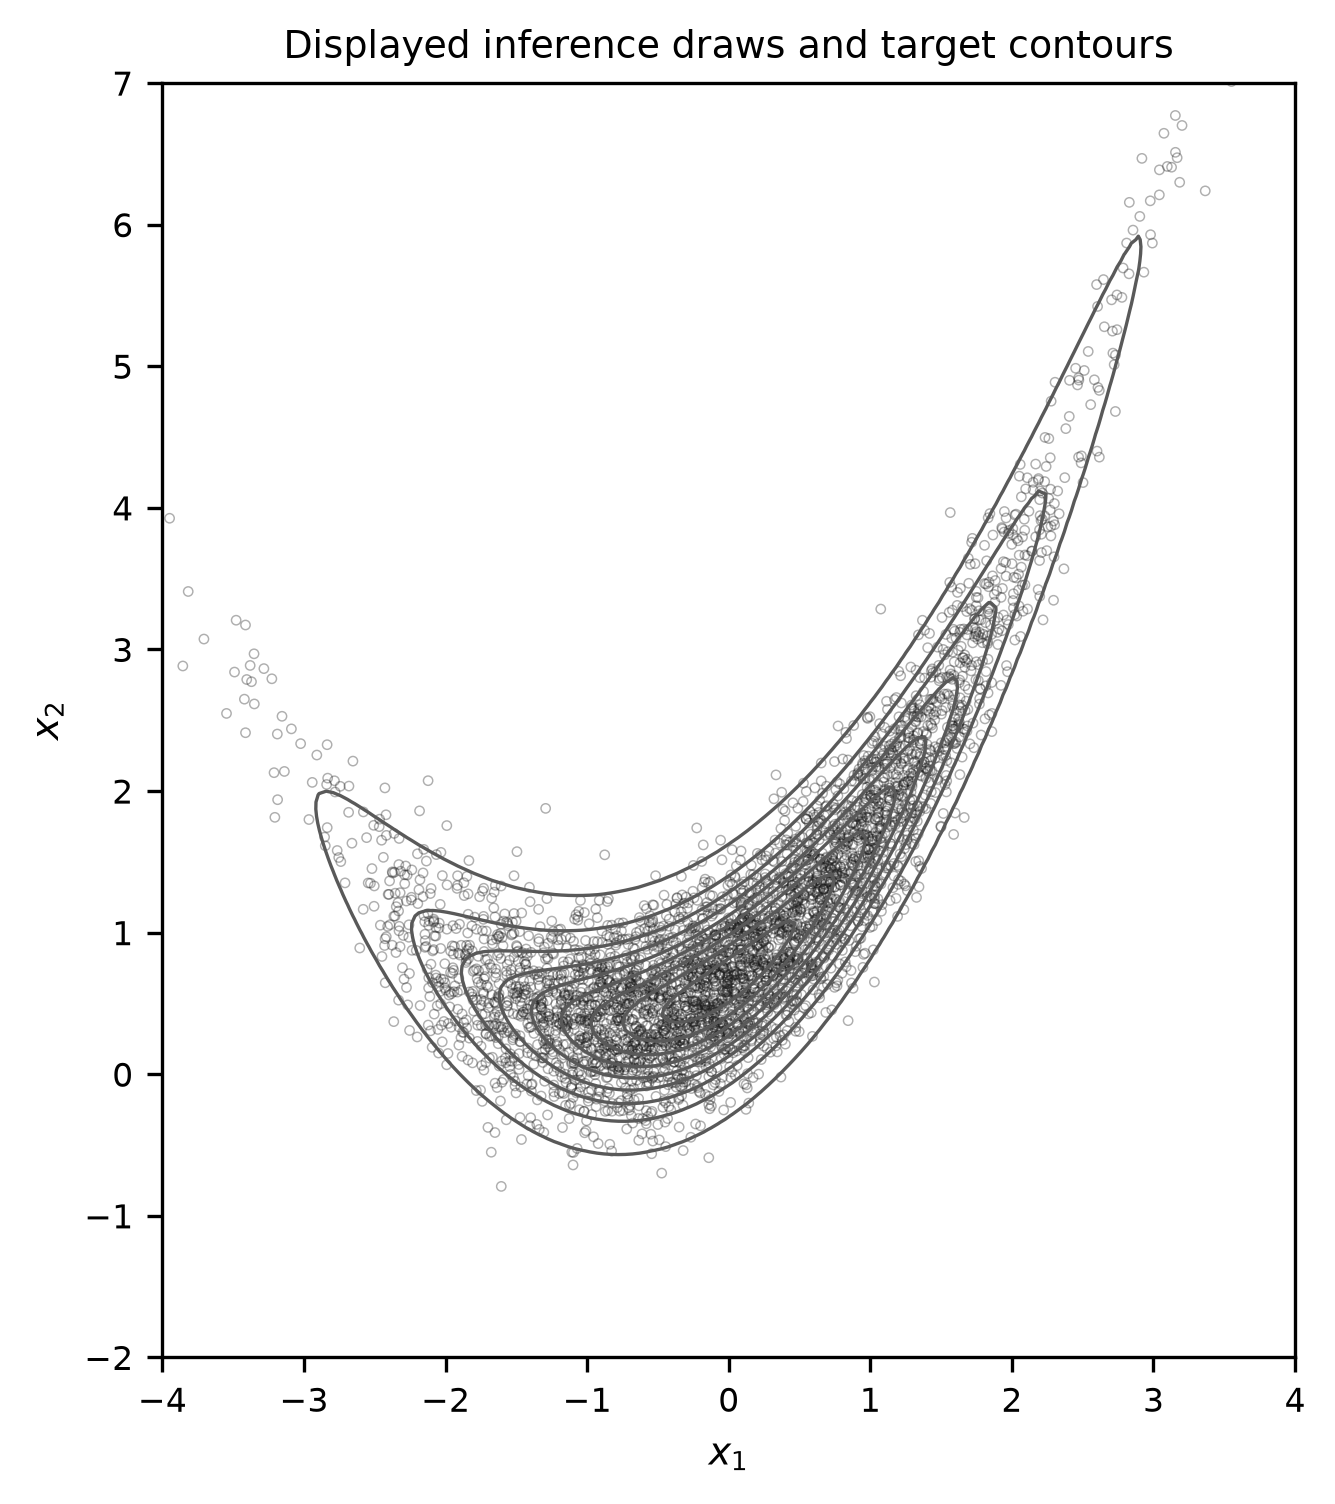

In [10]:
display_stride = 40
display_samples = np.asarray(samples[:, ::display_stride]).reshape(-1, 2)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"], constrained_layout=True)
draw_target_contours(ax)
ax.scatter(
    display_samples[:, 0],
    display_samples[:, 1],
    s=5,
    facecolors="none",
    edgecolors="0.10",
    linewidths=0.35,
    alpha=0.35,
    rasterized=True,
)
ax.set_title("Displayed inference draws and target contours");


## Diagnostic interpretation

For this stored run, the coordinate and moment $\widehat R$ values satisfy the $1.01$ warning screen, the rank plots show no clear chain separation, and the exact moments agree with the Monte Carlo estimates at the scale indicated by their MCSEs. These checks reveal no evident failure for the displayed quantities, but no finite diagnostic certifies convergence.

The effective sample sizes are nevertheless a small fraction of the $160{,}000$ retained states. The curved target forces an isotropic random walk to explore through many local moves. The next section uses gradients and Hamiltonian dynamics to make proposals that travel farther along this geometry.

## Exercises

1. Use a separate pilot run to compare several values of `proposal_scale`. Fix the selected value, generate fresh inference draws, and compare acceptance rate, $\widehat R$, bulk and tail ESS, and MCSE. Explain why acceptance rate alone is insufficient.
2. Move the four initial positions farther into the tails. Keep the warmup length fixed and assess whether the post-warmup chains still explore the same distribution. Use both trace and rank plots.
3. Construct an independent Metropolis--Hastings kernel with `blackjax.irmh`. Define one callable that draws $X'\sim q$ and another that evaluates $\log q(x')$ so that BlackJAX can include the Hastings correction. Compare a proposal with broad target coverage to one with poor overlap. If $q(x')=0$ on a region where $\pi(x')>0$, explain why the kernel is not $\pi$-irreducible, meaning that the chain cannot reach every region to which $\pi$ assigns positive probability from every starting state, and why invariance alone does not ensure convergence to $\pi$ from an arbitrary initial state.
